In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_appliction = pd.read_csv('./data/cleaned_data/applications.csv')

In [4]:
df_completions = pd.read_csv('./data/cleaned_data/completions.csv')

In [5]:
df_merged = df_appliction.merge(right = df_completions, how = 'inner', on='unique_id', suffixes=('_app' , '_comp'))

In [6]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7929 entries, 0 to 7928
Data columns (total 32 columns):
 #   Column                                                                               Non-Null Count  Dtype  
---  ------                                                                               --------------  -----  
 0   unique_id                                                                            7929 non-null   object 
 1   subscription_status                                                                  7929 non-null   object 
 2   voyage_role                                                                          7929 non-null   object 
 3   gender                                                                               7929 non-null   object 
 4   goal                                                                                 7929 non-null   object 
 5   source                                                                               7929 

In [7]:
# Step 2: Normalize 'completed_voyage'
df_merged['completed_voyage'] = df_merged['completed_voyage'].replace({
    'Yes': 'Yes',
    'TBD' : 'Yes',
    'No': 'No',
    'undefined': 'No'
})
# Step 3: Convert 'completed_voyage' to binary target
df_merged['completed_voyage'] = df_merged['completed_voyage'].map({'Yes': 1, 'No': 0})

In [8]:
# Inspect the columns to identify categorical fields to be binary encoded
categorical_columns = df_merged.select_dtypes(include='object').columns.tolist()

# Display merged DataFrame head and the identified categorical columns
df_merged.head(), categorical_columns

(                          unique_id subscription_status   voyage_role  gender  \
 0  dadffe486c63fc05d8b3afee2c4dc132              Active  Scrum Master  FEMALE   
 1  4e1e9195a8bdc244876ffd8fb954e5c8              Active     Developer    MALE   
 2  4e1e9195a8bdc244876ffd8fb954e5c8              Active     Developer    MALE   
 3  56a8ef8425ff0595bd660065cae07793              Active  Scrum Master  FEMALE   
 4  56a8ef8425ff0595bd660065cae07793              Active  Scrum Master  FEMALE   
 
               goal            source country_name_from_country  \
 0  GAIN EXPERIENCE   The Job Hackers                    Canada   
 1  GAIN EXPERIENCE  PERSONAL NETWORK                     India   
 2  GAIN EXPERIENCE  PERSONAL NETWORK                     India   
 3  GAIN EXPERIENCE  PERSONAL NETWORK            United Kingdom   
 4  GAIN EXPERIENCE  PERSONAL NETWORK            United Kingdom   
 
   voyage_from_voyage_signups  application_age_in_days application_day_of_week  \
 0                  

In [9]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7929 entries, 0 to 7928
Data columns (total 32 columns):
 #   Column                                                                               Non-Null Count  Dtype  
---  ------                                                                               --------------  -----  
 0   unique_id                                                                            7929 non-null   object 
 1   subscription_status                                                                  7929 non-null   object 
 2   voyage_role                                                                          7929 non-null   object 
 3   gender                                                                               7929 non-null   object 
 4   goal                                                                                 7929 non-null   object 
 5   source                                                                               7929 

In [10]:
from category_encoders import BinaryEncoder
import pandas as pd

# Step 1: Binary encode only categorical object columns
categorical_cols = df_merged.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['unique_id', 'timestamp']]

# Apply BinaryEncoder only to those categorical columns
binary_encoder = BinaryEncoder(cols=categorical_cols, return_df=True)
df_encoded = binary_encoder.fit_transform(df_merged)

# Step 2: Convert timestamp to datetime
df_encoded['timestamp'] = pd.to_datetime(df_merged['timestamp'])

# Step 3: Sort data
df_encoded = df_encoded.sort_values(by=['unique_id', 'timestamp'])

# Step 4: Select features
non_feature_cols = ['unique_id', 'subscription_status_dt',
                    'certificate_issue_date', 'application_date', 'updated_voyage_start_date' , 'timestamp']
feature_cols = [col for col in df_encoded.columns if col not in non_feature_cols + ['completed_voyage']]

# Step 5: Prepare sequences
sequence_data = []
sequence_targets = []

for uid, group in df_encoded.groupby('unique_id'):
    if len(group) < 2:
        continue
    X = group[feature_cols].to_numpy()
    y = group['completed_voyage'].to_numpy()
    sequence_data.append(X)
    sequence_targets.append(y)

# Summary
num_sequences = len(sequence_data)
seq_lengths = [len(seq) for seq in sequence_data]
min_len, max_len = min(seq_lengths), max(seq_lengths)

(num_sequences, min_len, max_len, len(feature_cols))


(666, 2, 224, 102)

In [11]:
for i, seq in enumerate(sequence_data[:5]):
    print(f"Sequence {i} dtype:", seq.dtype, " shape:", seq.shape)

Sequence 0 dtype: float64  shape: (9, 102)
Sequence 1 dtype: float64  shape: (49, 102)
Sequence 2 dtype: float64  shape: (2, 102)
Sequence 3 dtype: float64  shape: (4, 102)
Sequence 4 dtype: float64  shape: (2, 102)


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
from torch.nn.utils import clip_grad_norm_
import copy
from torch.nn.utils.rnn import pad_sequence

# Dataset prep — Clean & normalize BEFORE converting to tensor
# Convert to tensors and pad
sequence_tensor = [torch.tensor(seq, dtype=torch.float32) for seq in sequence_data]
target_tensor = [torch.tensor(seq, dtype=torch.float32) for seq in sequence_targets]

# Pad with zeros to the right (post-padding)
X_tensor = pad_sequence(sequence_tensor, batch_first=True)
y_tensor = pad_sequence(target_tensor, batch_first=True)

# Normalize X_tensor
X_tensor = torch.nan_to_num(X_tensor, nan=0.0, posinf=1e3, neginf=-1e3)
X_tensor = torch.clamp(X_tensor, -10, 10)
mean = X_tensor.mean(dim=(0, 1), keepdim=True)
std = X_tensor.std(dim=(0, 1), keepdim=True) + 1e-6
X_tensor = (X_tensor - mean) / std


class VoyageDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = VoyageDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
train_ds, test_ds = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# Updated model WITHOUT sigmoid
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.dropout(x)
        return self.classifier(x).squeeze(-1)  # shape: (batch, seq)

model = LSTMClassifier(X_tensor.shape[2])
criterion = nn.BCEWithLogitsLoss()  # handles raw logits directly
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
best_loss = float('inf')
patience = 3
wait = 0
best_model = copy.deepcopy(model.state_dict())

for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)

        if torch.isnan(logits).any() or torch.isinf(logits).any():
            continue

        yb = torch.clamp(yb, 0, 1)
        loss = criterion(logits, yb)

        if torch.isnan(loss): continue

        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
    
    # Move early stopping OUTSIDE the inner loop
    if total_loss < best_loss:
        best_loss = total_loss
        wait = 0
        best_model = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break
            

    
model.load_state_dict(best_model)
# Evaluation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.numel()

print(f"Test Accuracy: {correct / total:.4f}")


Epoch 1, Loss: 7.5875
Epoch 2, Loss: 1.2600
Epoch 3, Loss: 0.6945
Epoch 4, Loss: 0.6157
Epoch 5, Loss: 0.5710
Epoch 6, Loss: 0.5377
Epoch 7, Loss: 0.5045
Epoch 8, Loss: 0.4837
Epoch 9, Loss: 0.4535
Epoch 10, Loss: 0.4354
Test Accuracy: 0.9938


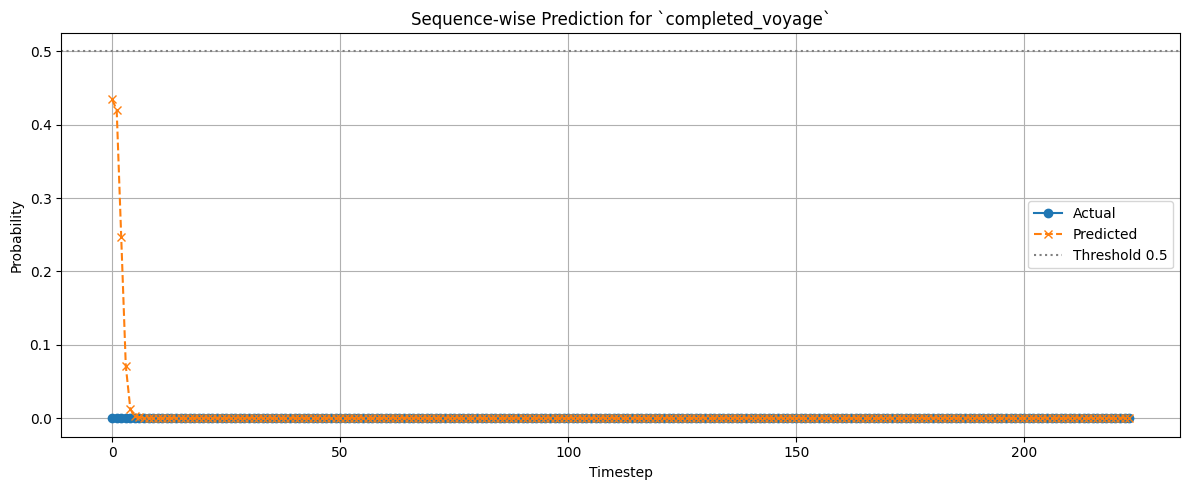

In [14]:
import matplotlib.pyplot as plt

# Pick a test sample (e.g. first one in test set)
sample_x, sample_y = test_ds[0]
sample_x = sample_x.unsqueeze(0)  # add batch dim: (1, seq_len, features)

# Predict
model.eval()
with torch.no_grad():
    logits = model(sample_x)
    probs = torch.sigmoid(logits).squeeze().numpy()  # shape: (seq_len,)
    ground_truth = sample_y.numpy()

# Visualize
plt.figure(figsize=(12, 5))
plt.plot(ground_truth, label='Actual', linestyle='-', marker='o')
plt.plot(probs, label='Predicted', linestyle='--', marker='x')
plt.axhline(0.5, color='gray', linestyle=':', label='Threshold 0.5')
plt.title("Sequence-wise Prediction for `completed_voyage`")
plt.xlabel("Timestep")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

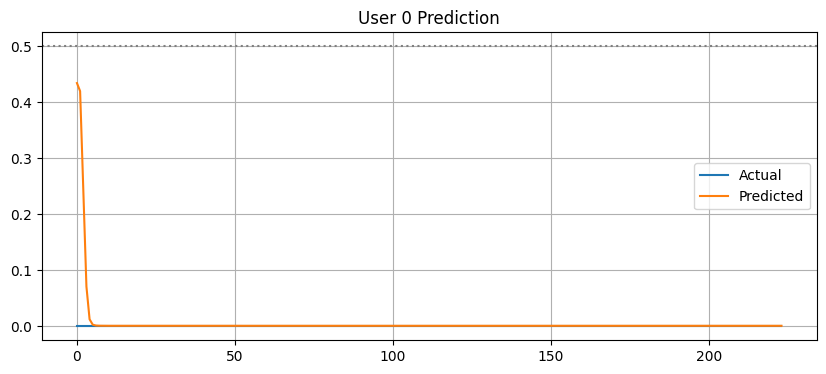

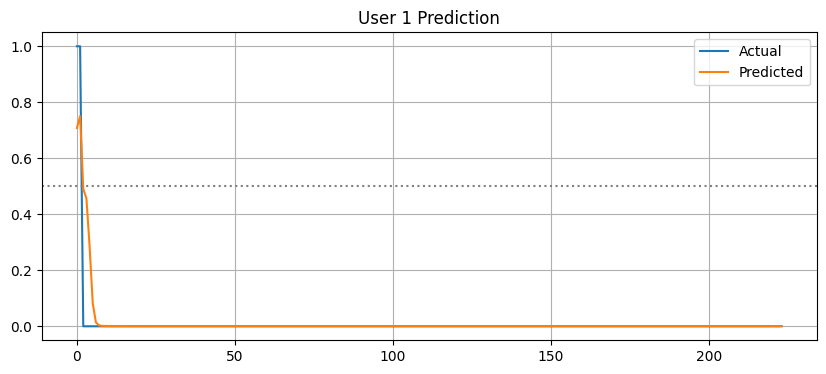

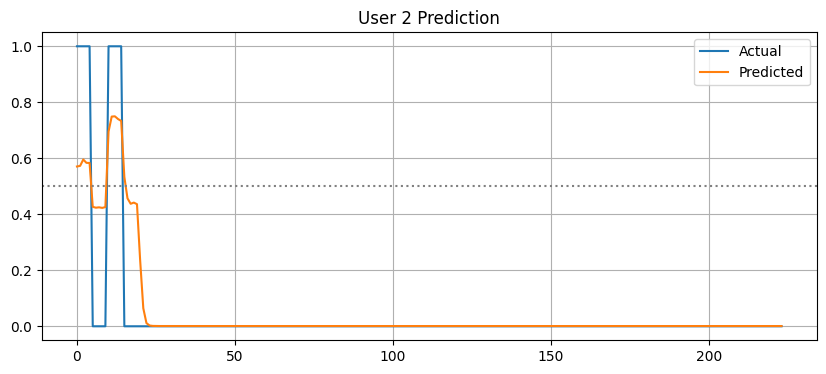

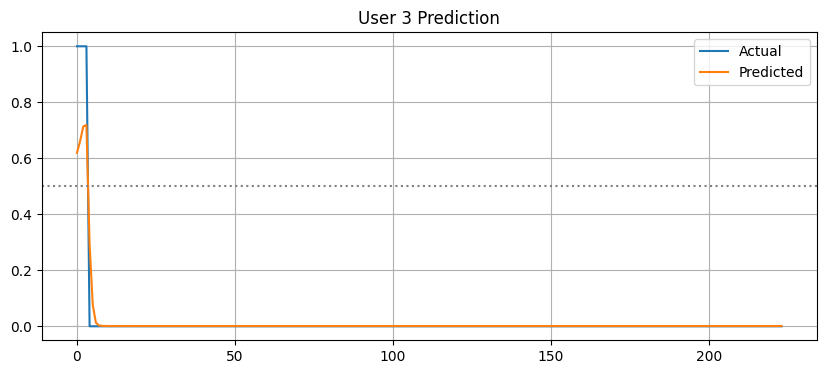

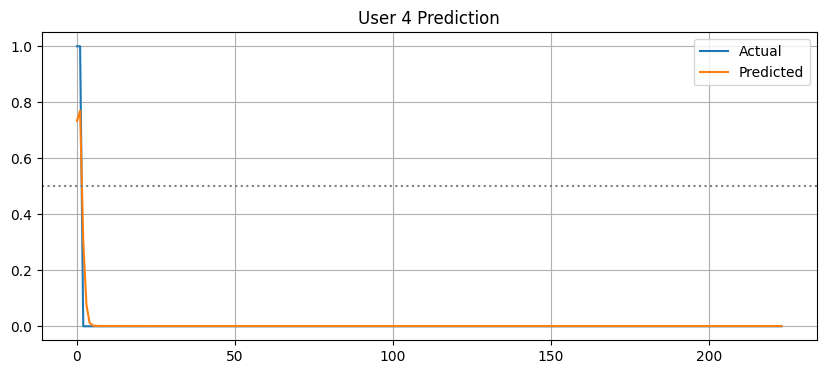

In [15]:
for i in range(5):  # show 5 users
    x, y = test_ds[i]
    logits = model(x.unsqueeze(0))
    probs = torch.sigmoid(logits).squeeze().detach().numpy()
    
    plt.figure(figsize=(10, 4))
    plt.plot(y.numpy(), label='Actual')
    plt.plot(probs, label='Predicted')
    plt.axhline(0.5, linestyle=':', color='gray')
    plt.title(f"User {i} Prediction")
    plt.legend()
    plt.grid(True)
    plt.show()


In [17]:
# Step 1: Parse and filter data
df_forecast = df_merged.copy()
df_forecast['timestamp'] = pd.to_datetime(df_forecast['timestamp'])
# df_forecast = df_forecast[df_forecast['completed_voyage'] == 1]

# Step 2: Monthly aggregation
monthly_counts = df_forecast.set_index('timestamp').resample('M').size().reset_index(name='voyage_completions')

# Step 3: Rename columns for Prophet
df_prophet = monthly_counts.rename(columns={'timestamp': 'ds', 'voyage_completions': 'y'})


In [18]:
pip install prophet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


11:39:48 - cmdstanpy - INFO - Chain [1] start processing
11:39:48 - cmdstanpy - INFO - Chain [1] done processing
11:39:48 - cmdstanpy - INFO - Chain [1] start processing
11:39:48 - cmdstanpy - INFO - Chain [1] start processing
11:39:48 - cmdstanpy - INFO - Chain [1] start processing
11:39:48 - cmdstanpy - INFO - Chain [1] start processing
11:39:48 - cmdstanpy - INFO - Chain [1] done processing
11:39:48 - cmdstanpy - INFO - Chain [1] done processing
11:39:48 - cmdstanpy - INFO - Chain [1] start processing
11:39:48 - cmdstanpy - INFO - Chain [1] done processing
11:39:49 - cmdstanpy - INFO - Chain [1] start processing
11:39:49 - cmdstanpy - INFO - Chain [1] start processing
11:39:49 - cmdstanpy - INFO - Chain [1] done processing
11:39:49 - cmdstanpy - INFO - Chain [1] done processing
11:39:49 - cmdstanpy - INFO - Chain [1] done processing
11:39:49 - cmdstanpy - INFO - Chain [1] done processing
11:39:49 - cmdstanpy - INFO - Chain [1] start processing
11:39:50 - cmdstanpy - INFO - Chain [1]

Best parameters:
 changepoint_prior_scale      0.500000
seasonality_prior_scale      1.000000
rmse                       150.604639
Name: 7, dtype: float64


11:40:00 - cmdstanpy - INFO - Chain [1] done processing


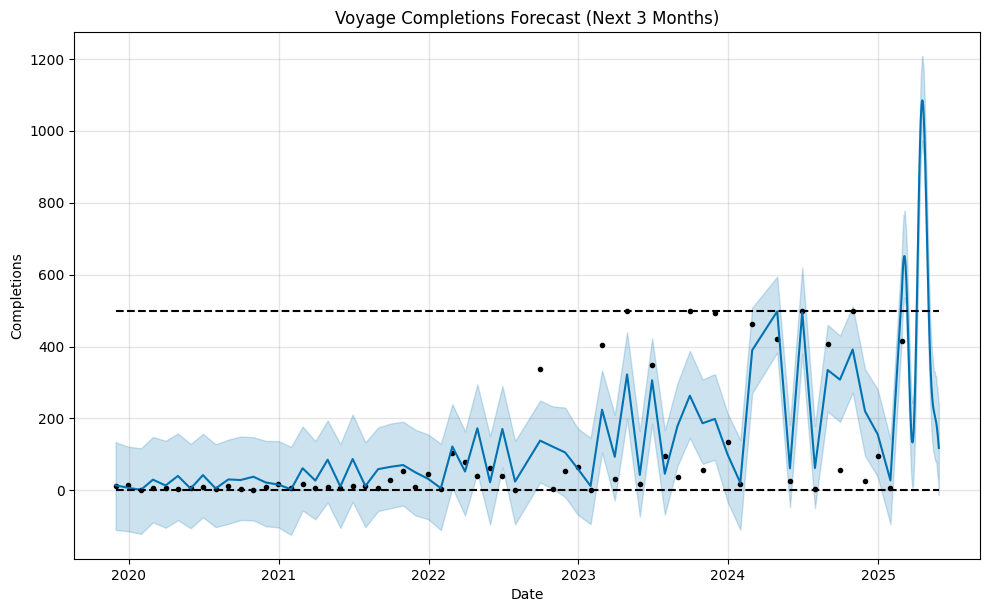

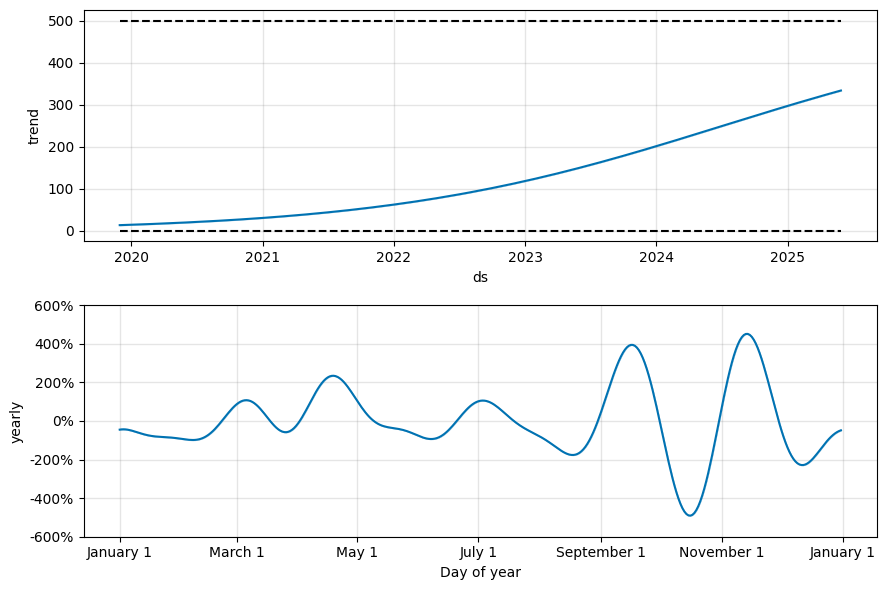

            ds        yhat  yhat_lower  yhat_upper
140 2025-05-18  214.548171   92.512486  330.924160
141 2025-05-19  209.601582   88.780911  330.427434
142 2025-05-20  204.661585   82.892462  318.284948
143 2025-05-21  199.328848   83.674382  319.438754
144 2025-05-22  193.263379   78.289341  317.058735
145 2025-05-23  186.195790   80.136348  305.162706
146 2025-05-24  177.936160   62.181895  290.849495
147 2025-05-25  168.380231   49.420125  288.351673
148 2025-05-26  157.512805   35.208924  274.183606
149 2025-05-27  145.408250   29.296619  264.934626
150 2025-05-28  132.228148   19.035403  245.902367
151 2025-05-29  118.216154  -11.505011  241.611001


In [24]:
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import itertools

# Prepare data
df_forecast = df_merged.copy()
df_forecast['timestamp'] = pd.to_datetime(df_forecast['timestamp'])

# Monthly aggregation
monthly_counts = df_forecast.set_index('timestamp').resample('M').size().reset_index(name='voyage_completions')

# Filter out zero or low completions (optional)
monthly_counts = monthly_counts[monthly_counts['voyage_completions'] > 0]

# Rename for Prophet
df_prophet = monthly_counts.rename(columns={'timestamp': 'ds', 'voyage_completions': 'y'})

# Cap outliers in completions
df_prophet['y'] = df_prophet['y'].clip(upper=500)

# Set logistic growth cap and floor
df_prophet['cap'] = 500
df_prophet['floor'] = 0

# Grid Search
param_grid = {
    'changepoint_prior_scale': [0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.1, 1.0, 5.0]
}
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
results = []

for params in all_params:
    model = Prophet(
        growth='logistic',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        holidays=None,
        seasonality_mode='multiplicative',  # Prevents seasonal swings from subtracting below 0
        **params
    )
    model.fit(df_prophet)

    df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='90 days', parallel="processes")
    df_perf = performance_metrics(df_cv)
    results.append({**params, 'rmse': df_perf['rmse'].mean()})

results_df = pd.DataFrame(results)
best_params = results_df.sort_values(by='rmse').iloc[0]
print("Best parameters:\n", best_params)

# Fit Final Model with Best Params 
model = Prophet(
    growth='logistic',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=None,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale']
)
model.fit(df_prophet)

# Forecast
future = model.make_future_dataframe(periods=90, freq='D')  # 3-month forecast
future['cap'] = 500
future['floor'] = 0

forecast = model.predict(future)

# Plot Results 
fig1 = model.plot(forecast)
plt.title("Voyage Completions Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Completions")
plt.grid(True)
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

# Show forecast table 
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12))


In [28]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 8.4 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from category_encoders.binary import BinaryEncoder

# --- Step 1: Aggregate df_merged monthly ---
df_merged['timestamp'] = pd.to_datetime(df_merged['timestamp'])
df_merged['month'] = df_merged['timestamp'].dt.to_period('M').dt.to_timestamp()

# Aggregate user data per month
agg = df_merged.groupby('month').agg({
    'unique_id': 'count',  # total applications
    'goal': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'country_name_from_country': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
    'subscription_status': lambda x: x.mode()[0] if not x.mode().empty else 'Unknown',
}).reset_index()

agg.rename(columns={
    'month': 'ds',
    'unique_id': 'total_apps',
    'goal': 'top_goal',
    'country_name_from_country': 'top_country',
    'subscription_status': 'top_status'
}, inplace=True)

# --- Step 2: Encode categorical features with BinaryEncoder ---
encoder = BinaryEncoder(cols=['top_goal', 'top_country', 'top_status'])
encoded_agg = encoder.fit_transform(agg)

# --- Step 3: Merge with Prophet forecast and actuals ---
df_features = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
df_features = df_features.merge(encoded_agg, on='ds', how='left')
df_features = df_features.merge(df_prophet[['ds', 'y']], on='ds', how='left')
df_features = df_features.dropna(subset=['y'])  # keep only rows with actual y
df_features['residual'] = df_features['y'] - df_features['yhat']
# --- Step 4: Time-based split into interpolation vs. extrapolation ---
split_date = pd.to_datetime("2024-12-31")
df_interp = df_features[df_features['ds'] <= split_date].copy()
df_extra = df_features[df_features['ds'] > split_date].copy()

# --- Step 5: Train/test split on interpolation set ---
X_interp = df_interp.drop(columns=['ds', 'y'])
y_interp = df_interp['y']
X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

# --- Step 6: Grid Search for XGBoost ---
param_grid = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [100, 200]
}
xgb_model = xgb.XGBRegressor()
grid_search = GridSearchCV(xgb_model, param_grid, cv=3, scoring='neg_root_mean_squared_error')
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)

# --- Step 7: Evaluate ---
best_model = grid_search.best_estimator_

# On interpolation test
interp_preds = best_model.predict(X_test)
from math import sqrt
interp_rmse = sqrt(mean_squared_error(y_test, interp_preds))
print(f" Interpolation RMSE: {interp_rmse:.2f}")

# On extrapolation (if available)
if not df_extra.empty:
    X_extra = df_extra.drop(columns=['ds', 'y'])
    y_extra = df_extra['y']
    extra_preds = best_model.predict(X_extra)
    extra_rmse = sqrt(mean_squared_error(y_extra, extra_preds))
    print(f" Extrapolation RMSE: {extra_rmse:.2f}")
else:
    print(" No extrapolation data available.")


Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
 Interpolation RMSE: 60.00
 Extrapolation RMSE: 15.76


In [43]:
# --- Step 2.5: Decode binary-encoded mappings for top_goal, top_country, and top_status ---

# Use known dummy values for non-target fields
dummy_ds = agg['ds'].iloc[0]
dummy_apps = agg['total_apps'].iloc[0]
unique_goals = agg['top_goal'].astype(str).unique()
unique_countries = agg['top_country'].astype(str).unique()
unique_statuses = agg['top_status'].astype(str).unique()

# Create combined cartesian product for all unique categorical values
import itertools

combinations = list(itertools.product(unique_goals, unique_countries, unique_statuses))
combo_df = pd.DataFrame(combinations, columns=['top_goal', 'top_country', 'top_status'])
combo_df['ds'] = dummy_ds
combo_df['total_apps'] = dummy_apps
combo_df = combo_df[['ds', 'total_apps', 'top_goal', 'top_country', 'top_status']]  # Match original column order

# Encode using fitted encoder
encoded_combos = encoder.transform(combo_df)

# Helper: Decode binary for any column group
def decode_binary(encoded_df, prefix):
    bin_cols = [col for col in encoded_df.columns if col.startswith(prefix)]
    binary_strs = encoded_df[bin_cols].astype(str).agg(''.join, axis=1)
    return binary_strs.apply(lambda x: int(x, 2))

# Add decoded values for each feature
encoded_combos['goal_encoded'] = decode_binary(encoded_combos, 'top_goal_')
encoded_combos['country_encoded'] = decode_binary(encoded_combos, 'top_country_')
encoded_combos['status_encoded'] = decode_binary(encoded_combos, 'top_status_')

# Final table
decoded_map = pd.concat([
    combo_df[['top_goal', 'top_country', 'top_status']].reset_index(drop=True),
    encoded_combos[['goal_encoded', 'country_encoded', 'status_encoded']]
], axis=1)

# Show results
print("\nDecoded binary encoding for all categorical fields:")
print(decoded_map.sort_values(['country_encoded', 'goal_encoded']).to_string(index=False))


Decoded binary encoding for all categorical fields:
                     top_goal        top_country   top_status  goal_encoded  country_encoded  status_encoded
          ACCELERATE LEARNING            Denmark       Active             1                1               1
          ACCELERATE LEARNING            Denmark Unsubscribed             1                1               2
              GAIN EXPERIENCE            Denmark       Active             2                1               1
              GAIN EXPERIENCE            Denmark Unsubscribed             2                1               2
                        other            Denmark       Active             3                1               1
                        other            Denmark Unsubscribed             3                1               2
GET OUT OF TUTORIAL PURGATORY            Denmark       Active             4                1               1
GET OUT OF TUTORIAL PURGATORY            Denmark Unsubscribed             4

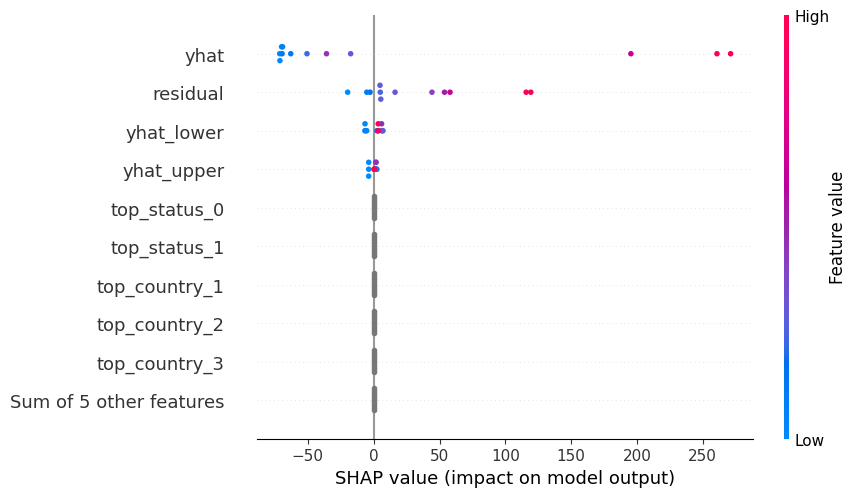

In [34]:
import shap
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

In [44]:
def build_bit_table(decoded_df, label_col, encoded_col, prefix):
    df = decoded_df[[label_col, encoded_col]].drop_duplicates()
    # Ensure 3-digit binary
    df['binary'] = df[encoded_col].apply(lambda x: format(x, '03b'))
    # Extract individual bits
    df[f'{prefix}_1'] = df['binary'].str[0].astype(int)  # MSB
    df[f'{prefix}_2'] = df['binary'].str[1].astype(int)
    df[f'{prefix}_3'] = df['binary'].str[2].astype(int)
    return df[[label_col, encoded_col, f'{prefix}_1', f'{prefix}_2', f'{prefix}_3']]

# Apply for country and status
country_bits = build_bit_table(decoded_map, 'top_country', 'country_encoded', 'top_country')
status_bits = build_bit_table(decoded_map, 'top_status', 'status_encoded', 'top_status')

print("\nBit breakdown for countries (linked to SHAP top_country_*):")
print(country_bits.to_string(index=False))

print("\nBit breakdown for statuses (linked to SHAP top_status_*):")
print(status_bits.to_string(index=False))


Bit breakdown for countries (linked to SHAP top_country_*):
       top_country  country_encoded  top_country_1  top_country_2  top_country_3
           Denmark                1              0              0              1
    United Kingdom                2              0              1              0
            Canada                3              0              1              1
     United States                4              1              0              0
           Germany                5              1              0              1
       Philippines                6              1              1              0
           Czechia                7              1              1              1
             India                8              1              0              0
           Nigeria                9              1              0              0
         Australia               10              1              0              1
Republic of Serbia               11             

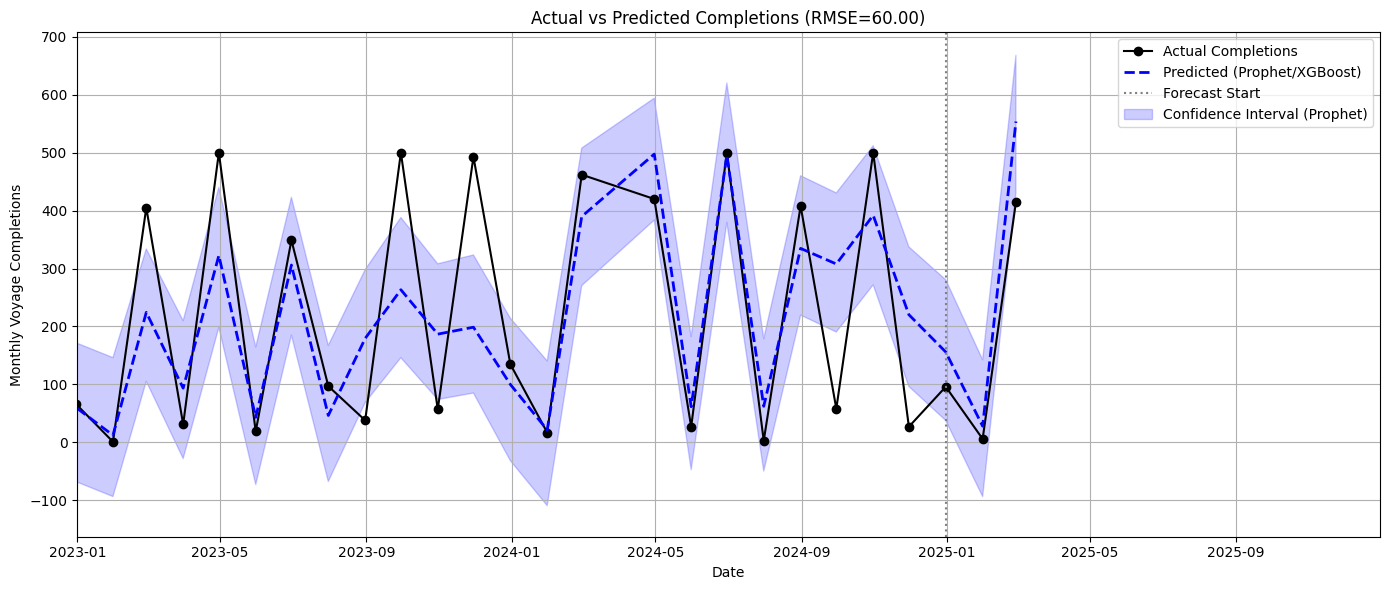

In [39]:
import matplotlib.pyplot as plt

# Make sure your df_features DataFrame includes:
# 'ds' (datetime), 'y' (actual), 'yhat', 'yhat_lower', 'yhat_upper'

plt.figure(figsize=(14, 6))

# Plot actual values
plt.plot(df_features['ds'], df_features['y'], label='Actual Completions', color='black', marker='o', linewidth=1.5)

# Plot forecasted values
plt.plot(df_features['ds'], df_features['yhat'], label='Predicted (Prophet/XGBoost)', color='blue', linestyle='--', linewidth=2)

plt.axvline(pd.to_datetime("2024-12-31"), color='gray', linestyle=':', label='Forecast Start')

# Plot confidence intervals (from Prophet)
plt.fill_between(df_features['ds'], df_features['yhat_lower'], df_features['yhat_upper'],
                 color='blue', alpha=0.2, label='Confidence Interval (Prophet)')

# Formatting
plt.xlabel("Date")
plt.ylabel("Monthly Voyage Completions")
plt.title(f"Actual vs Predicted Completions (RMSE={interp_rmse:.2f})")
plt.xlim(pd.to_datetime("2023-01-01"), pd.to_datetime("2025-12-31"))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


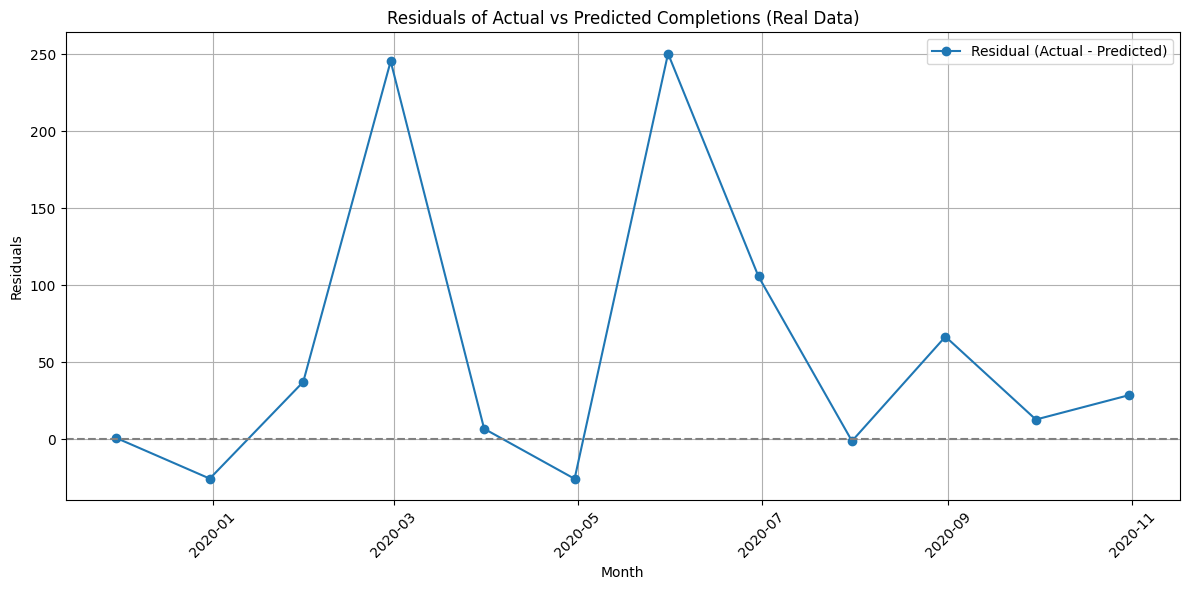

In [32]:
# Build the residual plot and detect outliers after user re-provided pipeline code
df_interp_plot = df_interp[['ds']].copy()
df_interp_plot['actual'] = y_test.reset_index(drop=True)
df_interp_plot['predicted'] = pd.Series(interp_preds).reset_index(drop=True)

if not df_extra.empty:
    df_extra_plot = df_extra[['ds']].copy()
    df_extra_plot['actual'] = y_extra.reset_index(drop=True)
    df_extra_plot['predicted'] = pd.Series(extra_preds).reset_index(drop=True)
    df_plot = pd.concat([df_interp_plot, df_extra_plot], ignore_index=True)
else:
    df_plot = df_interp_plot.copy()

# Calculate residuals
df_plot['residual'] = df_plot['actual'] - df_plot['predicted']

# Identify outliers: residuals far from 0 using std threshold
threshold = df_plot['residual'].std() * 2
df_outliers = df_plot[abs(df_plot['residual']) > threshold]

# Plot residuals
plt.figure(figsize=(12, 6))
plt.plot(df_plot['ds'], df_plot['residual'], marker='o', linestyle='-', label='Residual (Actual - Predicted)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title("Residuals of Actual vs Predicted Completions (Real Data)")
plt.xlabel("Month")
plt.ylabel("Residuals")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

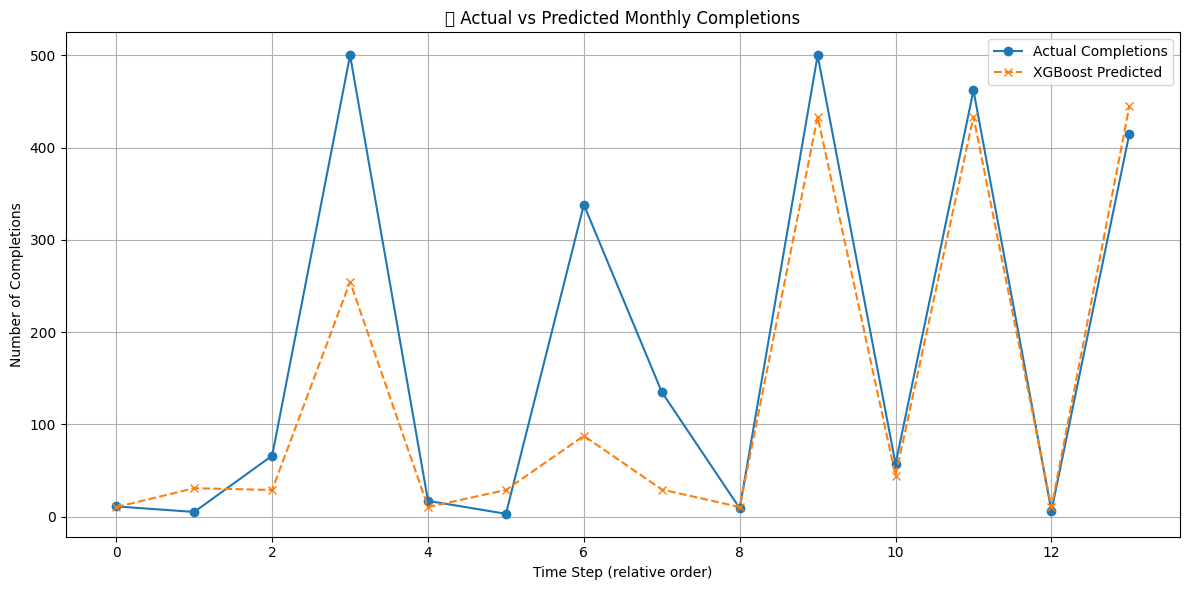

In [31]:
import matplotlib.pyplot as plt

# Reconstruct actual and predicted values for visualization
interp_actual = y_test.reset_index(drop=True)
interp_pred = pd.Series(interp_preds, name='Predicted').reset_index(drop=True)

# If extrapolation exists
if not df_extra.empty:
    extra_actual = y_extra.reset_index(drop=True)
    extra_pred = pd.Series(extra_preds, name='Predicted').reset_index(drop=True)

    # Combine for full series
    actual_all = pd.concat([interp_actual, extra_actual], ignore_index=True)
    pred_all = pd.concat([interp_pred, extra_pred], ignore_index=True)
    labels = ['Interp'] * len(interp_actual) + ['Extra'] * len(extra_actual)
else:
    actual_all = interp_actual
    pred_all = interp_pred
    labels = ['Interp'] * len(interp_actual)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(actual_all, marker='o', label='Actual Completions')
plt.plot(pred_all, marker='x', linestyle='--', label='XGBoost Predicted')
plt.title("Actual vs Predicted Monthly Completions")
plt.xlabel("Time Step (relative order)")
plt.ylabel("Number of Completions")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [165]:
pip install pandas-datareader

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [241]:
import pandas_datareader.data as web
import datetime

start = datetime.datetime(2020, 1, 1)
end = datetime.datetime(2026, 12, 31)

# Example: U.S. Unemployment Rate
labor_data = web.DataReader('UNRATE', 'fred', start, end)
labor_data = labor_data.reset_index().rename(columns={'DATE': 'ds', 'UNRATE': 'unemployment_rate'})


In [242]:
labor_data

,ds,unemployment_rate
0,2020-01-01,3.6
1,2020-02-01,3.5
2,2020-03-01,4.4
3,2020-04-01,14.8
4,2020-05-01,13.2
...,...,...
59,2024-12-01,4.1
60,2025-01-01,4.0
61,2025-02-01,4.1
62,2025-03-01,4.2


In [243]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,Christmas Day,Christmas Day_lower,Christmas Day_upper,Christmas Day (observed),...,holidays,holidays_lower,holidays_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-07-31,-28.897978,-184.017602,-7.105906,-28.897978,-28.897978,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-58.630315,-58.630315,-58.630315,0.0,0.0,0.0,-87.528293
1,2021-08-31,-24.279108,-45.261889,124.490805,-24.279108,-24.279108,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,61.591482,61.591482,61.591482,0.0,0.0,0.0,37.312373
2,2021-09-30,-19.809234,-85.329617,83.088846,-19.809234,-19.809234,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,20.779334,20.779334,20.779334,0.0,0.0,0.0,0.970100
3,2021-10-31,-15.190364,55.451405,233.670434,-15.190364,-15.190364,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,158.733102,158.733102,158.733102,0.0,0.0,0.0,143.542737
4,2021-11-30,-10.720490,-111.408251,57.856841,-10.720490,-10.720490,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-19.638193,-19.638193,-19.638193,0.0,0.0,0.0,-30.358684


In [244]:
start = datetime.datetime(2021, 7, 1)
end = datetime.datetime(2026, 12, 31)

# Get monthly unemployment rate
labor_data = web.DataReader('UNRATE', 'fred', start, end)
labor_data = labor_data.resample('M').mean()  # ensures it's monthly
labor_data = labor_data.reset_index().rename(columns={'DATE': 'ds', 'UNRATE': 'unemployment_rate'})

In [245]:
labor_data.head()

,ds,unemployment_rate
0,2021-07-31,5.4
1,2021-08-31,5.1
2,2021-09-30,4.7
3,2021-10-31,4.5
4,2021-11-30,4.2


In [246]:
combined = pd.merge(forecast[['ds', 'yhat']], labor_data, on='ds', how='inner')

In [247]:
combined.head()

,ds,yhat,unemployment_rate
0,2021-07-31,-87.528293,5.4
1,2021-08-31,37.312373,5.1
2,2021-09-30,0.970100,4.7
3,2021-10-31,143.542737,4.5
4,2021-11-30,-30.358684,4.2


In [179]:
start_date = pd.to_datetime(df_merged['timestamp']).min()
combined = combined[combined['ds'] >= start_date]

In [180]:
combined.head()

,ds,yhat,unemployment_rate
0,2021-07-31,-87.528293,5.4
1,2021-08-31,37.312373,5.1
2,2021-09-30,0.970100,4.7
3,2021-10-31,143.542737,4.5
4,2021-11-30,-30.358684,4.2


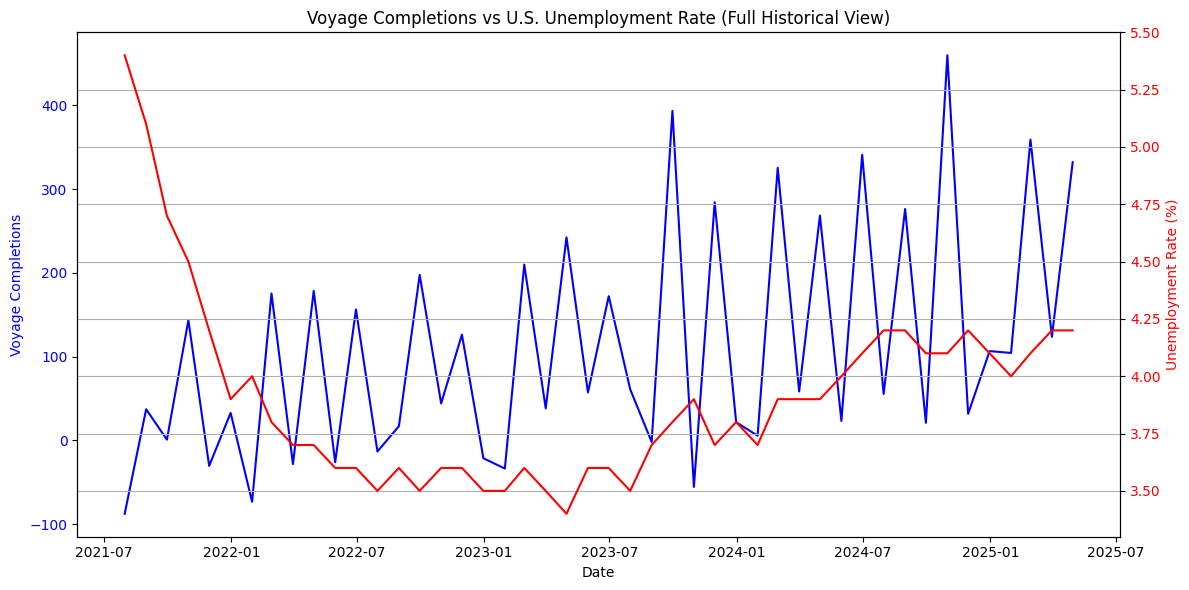

In [248]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Date')
ax1.set_ylabel('Voyage Completions', color='blue')
ax1.plot(combined['ds'], combined['yhat'], color='blue', label='Voyage Completions')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Unemployment Rate (%)', color='red')
ax2.plot(combined['ds'], combined['unemployment_rate'], color='red', label='Unemployment Rate')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Voyage Completions vs U.S. Unemployment Rate (Full Historical View)')
plt.grid(True)
fig.tight_layout()
plt.show()

### Application Date

In [249]:
import re

df_merged['has_valid_voyage'] = df_merged['updated_voyage_number'].apply(
    lambda v: 1 if pd.notnull(v) and re.fullmatch(r'V\d{1,2}', str(v)) and v not in ['V99', 'V999'] else 0
)


In [250]:
# Step 1: Binary encode only categorical object columns
categorical_cols = df_merged.select_dtypes(include='object').columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['unique_id', 'application_date']]

# Apply BinaryEncoder only to those categorical columns
binary_encoder = BinaryEncoder(cols=categorical_cols, return_df=True)
df_encoded = binary_encoder.fit_transform(df_merged)

# Step 2: Convert Application Date to datetime
df_encoded['application_date'] = pd.to_datetime(df_merged['application_date'])

# Step 3: Sort data
df_encoded = df_encoded.sort_values(by=['unique_id', 'application_date'])

# Step 4: Select features
non_feature_cols = ['unique_id', 'subscription_status_dt',
                    'certificate_issue_date', 'application_date', 'updated_voyage_start_date' , 'timestamp']
feature_cols = [col for col in df_encoded.columns if col not in non_feature_cols + ['has_valid_voyage']]

# Step 5: Prepare sequences
sequence_data = []
sequence_targets = []

for uid, group in df_encoded.groupby('unique_id'):
    if len(group) < 2:
        continue
    X = group[feature_cols].to_numpy()
    y = group['has_valid_voyage'].to_numpy()
    sequence_data.append(X)
    sequence_targets.append(y)

# Summary
num_sequences = len(sequence_data)
seq_lengths = [len(seq) for seq in sequence_data]
min_len, max_len = min(seq_lengths), max(seq_lengths)

(num_sequences, min_len, max_len, len(feature_cols))


(666, 2, 224, 103)

In [251]:
for i, seq in enumerate(sequence_data[:5]):
    print(f"Sequence {i} dtype:", seq.dtype, " shape:", seq.shape)

Sequence 0 dtype: float64  shape: (9, 103)
Sequence 1 dtype: float64  shape: (49, 103)
Sequence 2 dtype: float64  shape: (2, 103)
Sequence 3 dtype: float64  shape: (4, 103)
Sequence 4 dtype: float64  shape: (2, 103)


In [252]:
# Dataset prep — Clean & normalize BEFORE converting to tensor
# Convert to tensors and pad
sequence_tensor = [torch.tensor(seq, dtype=torch.float32) for seq in sequence_data]
target_tensor = [torch.tensor(seq, dtype=torch.float32) for seq in sequence_targets]

# Pad with zeros to the right (post-padding)
X_tensor = pad_sequence(sequence_tensor, batch_first=True)
y_tensor = pad_sequence(target_tensor, batch_first=True)

# Normalize X_tensor
X_tensor = torch.nan_to_num(X_tensor, nan=0.0, posinf=1e3, neginf=-1e3)
X_tensor = torch.clamp(X_tensor, -10, 10)
mean = X_tensor.mean(dim=(0, 1), keepdim=True)
std = X_tensor.std(dim=(0, 1), keepdim=True) + 1e-6
X_tensor = (X_tensor - mean) / std


class VoyageDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = VoyageDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
train_ds, test_ds = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32)

# Updated model WITHOUT sigmoid
class LSTMClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, 1)
    
    def forward(self, x):
        x, _ = self.lstm(x)
        x = self.dropout(x)
        return self.classifier(x).squeeze(-1)  # shape: (batch, seq)

model = LSTMClassifier(X_tensor.shape[2])
criterion = nn.BCEWithLogitsLoss()  # handles raw logits directly
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
best_loss = float('inf')
patience = 3
wait = 0
best_model = copy.deepcopy(model.state_dict())

for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)

        if torch.isnan(logits).any() or torch.isinf(logits).any():
            continue

        yb = torch.clamp(yb, 0, 1)
        loss = criterion(logits, yb)

        if torch.isnan(loss): continue

        loss.backward()
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")
    
    # Move early stopping OUTSIDE the inner loop
    if total_loss < best_loss:
        best_loss = total_loss
        wait = 0
        best_model = copy.deepcopy(model.state_dict())
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break
            

    
model.load_state_dict(best_model)
# Evaluation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.numel()

print(f"Test Accuracy: {correct / total:.4f}")

Epoch 1, Loss: 8.4320
Epoch 2, Loss: 1.5173
Epoch 3, Loss: 0.4746
Epoch 4, Loss: 0.3261
Epoch 5, Loss: 0.2626
Epoch 6, Loss: 0.2258
Epoch 7, Loss: 0.2002
Epoch 8, Loss: 0.1813
Epoch 9, Loss: 0.1650
Epoch 10, Loss: 0.1521
Test Accuracy: 0.9988


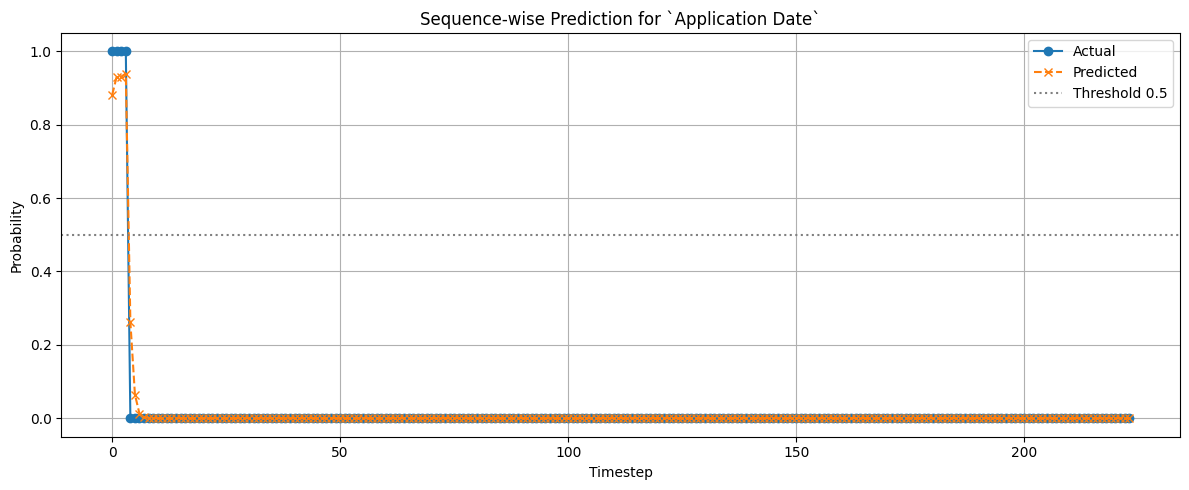

In [186]:
import matplotlib.pyplot as plt

# Pick a test sample (e.g. first one in test set)
sample_x, sample_y = test_ds[0]
sample_x = sample_x.unsqueeze(0)  # add batch dim: (1, seq_len, features)

# Predict
model.eval()
with torch.no_grad():
    logits = model(sample_x)
    probs = torch.sigmoid(logits).squeeze().numpy()  # shape: (seq_len,)
    ground_truth = sample_y.numpy()

# Visualize
plt.figure(figsize=(12, 5))
plt.plot(ground_truth, label='Actual', linestyle='-', marker='o')
plt.plot(probs, label='Predicted', linestyle='--', marker='x')
plt.axhline(0.5, color='gray', linestyle=':', label='Threshold 0.5')
plt.title("Sequence-wise Prediction for `Application Date`")
plt.xlabel("Timestep")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


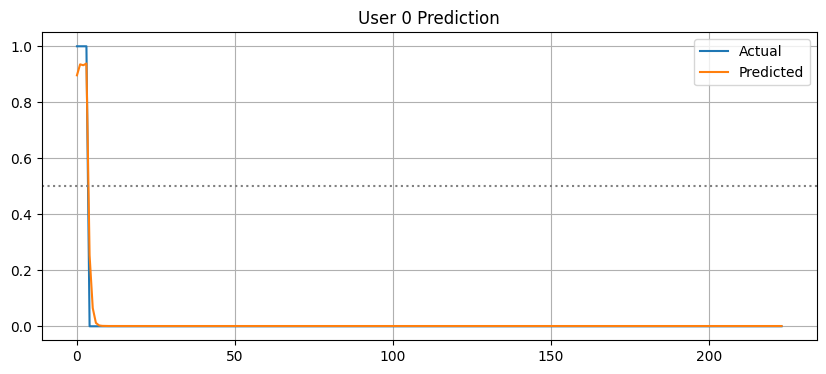

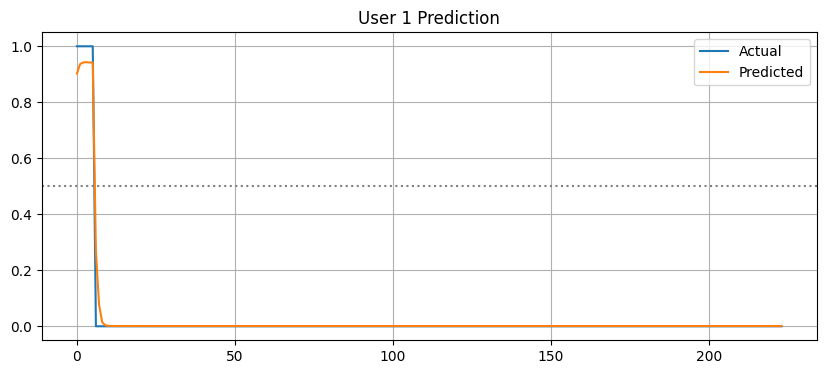

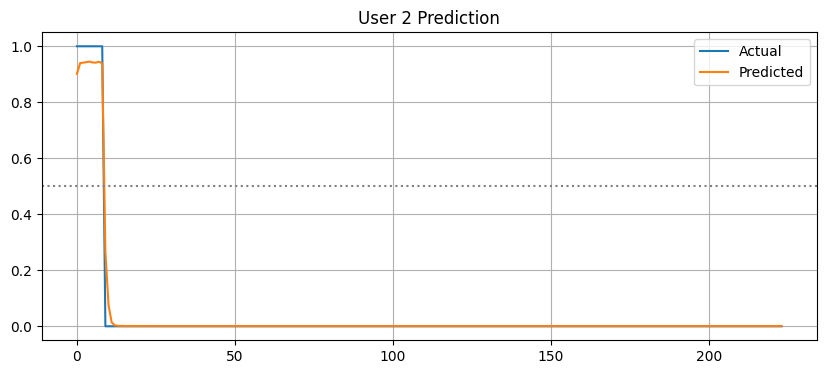

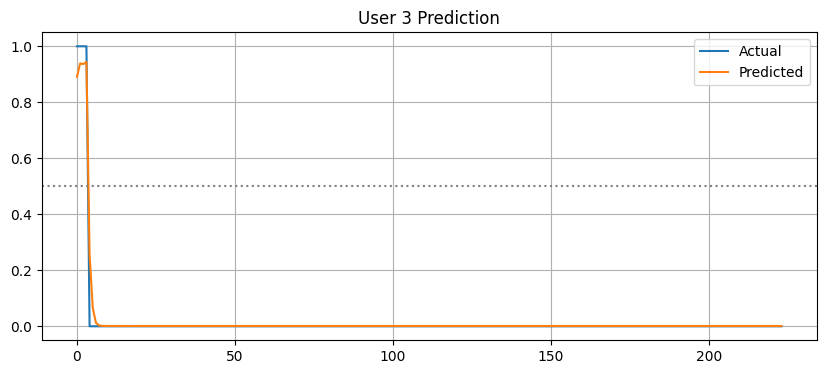

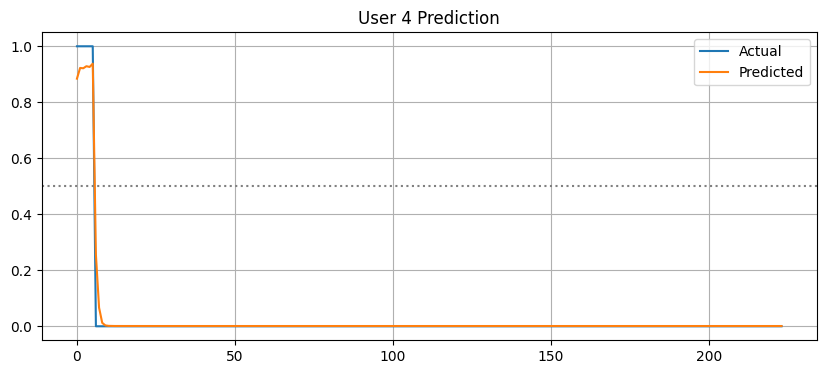

In [253]:
for i in range(5):  # show 5 users
    x, y = test_ds[i]
    logits = model(x.unsqueeze(0))
    probs = torch.sigmoid(logits).squeeze().detach().numpy()
    
    plt.figure(figsize=(10, 4))
    plt.plot(y.numpy(), label='Actual')
    plt.plot(probs, label='Predicted')
    plt.axhline(0.5, linestyle=':', color='gray')
    plt.title(f"User {i} Prediction")
    plt.legend()
    plt.grid(True)
    plt.show()

15:07:30 - cmdstanpy - INFO - Chain [1] start processing
15:07:30 - cmdstanpy - INFO - Chain [1] done processing


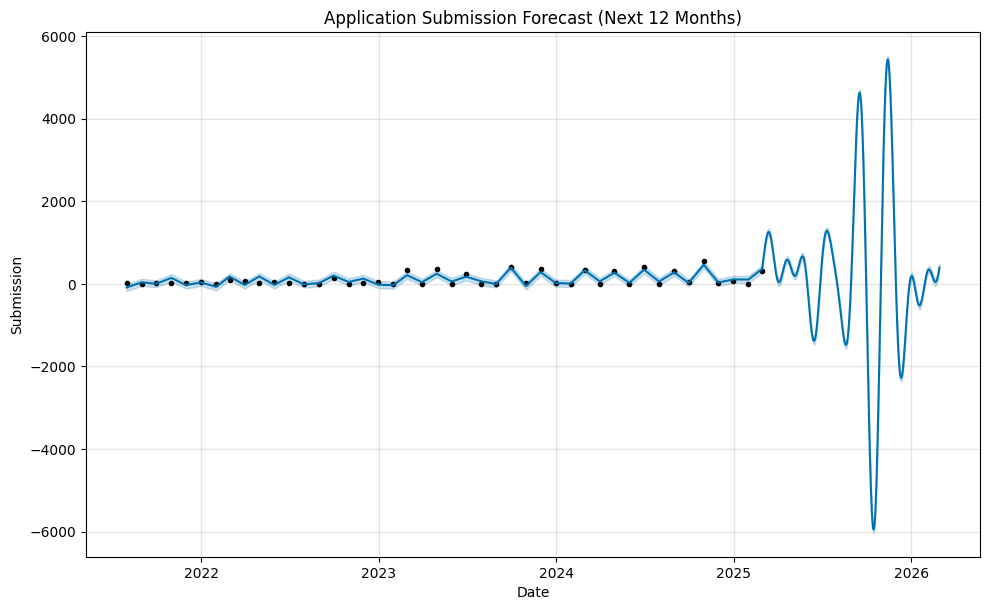

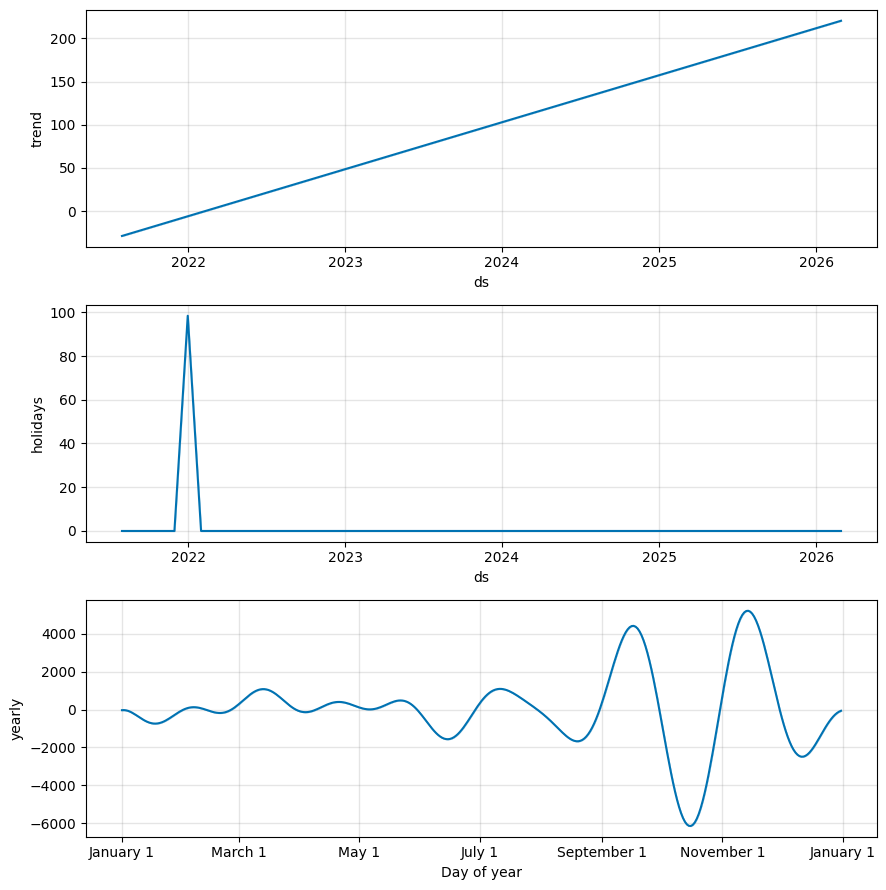

,ds,yhat,yhat_lower,yhat_upper
397,2026-02-17,78.133516,-7.219786,159.603943
398,2026-02-18,58.354851,-29.158695,146.426684
399,2026-02-19,46.383317,-48.555587,132.640498
400,2026-02-20,43.419517,-39.580347,137.781089
401,2026-02-21,50.407503,-37.530027,131.732119
402,2026-02-22,68.004377,-23.280581,158.200795
403,2026-02-23,96.558047,9.001549,177.726573
404,2026-02-24,136.093765,55.298200,218.648427
405,2026-02-25,186.309851,100.965533,268.952101
406,2026-02-26,246.582708,161.274660,332.847441


In [254]:
# Step 1: Prepare data (already done earlier)
# df_prophet = DataFrame with columns ['ds', 'y']

# Step 2: Initialize and fit Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.add_country_holidays(country_name='US')
model.fit(df_prophet)

# Step 3: Create 12-month future dataframe
future = model.make_future_dataframe(periods=365, freq='D')

# Step 4: Forecast
forecast = model.predict(future)

# Step 5: Plot
fig1 = model.plot(forecast)
plt.title("Application Submission Forecast (Next 12 Months)")
plt.xlabel("Date")
plt.ylabel("Submission")
plt.grid(True)
plt.show()

# Optional: Components plot
fig2 = model.plot_components(forecast)
plt.show()

# Optional: Show forecasted numbers
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

In [255]:
combined = pd.merge(forecast[['ds', 'yhat']], labor_data, on='ds', how='inner')

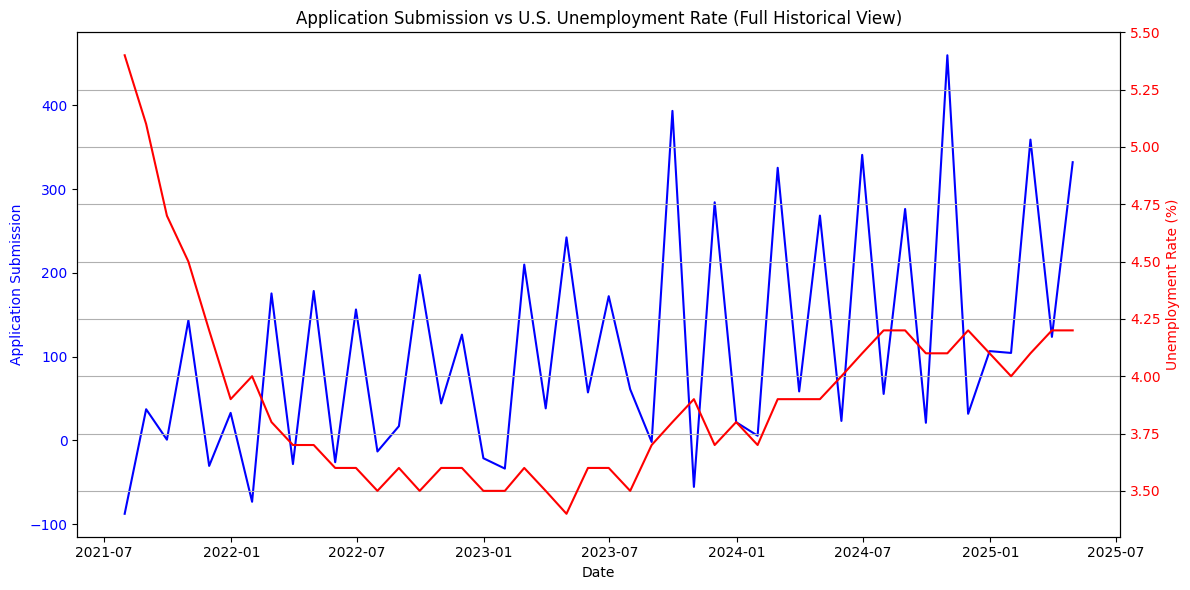

In [256]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Date')
ax1.set_ylabel('Application Submission', color='blue')
ax1.plot(combined['ds'], combined['yhat'], color='blue', label='Application submission')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Unemployment Rate (%)', color='red')
ax2.plot(combined['ds'], combined['unemployment_rate'], color='red', label='Unemployment Rate')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Application Submission vs U.S. Unemployment Rate (Full Historical View)')
plt.grid(True)
fig.tight_layout()
plt.show()

In [257]:
df_trends = pd.read_csv("./data/multiTimeline_web_development.csv", skiprows=1)
df_trends.columns = ['date', 'interest']
df_trends['date'] = pd.to_datetime(df_trends['date'])

In [258]:
df_trends.head()

,date,interest
0,2020-05-10,78
1,2020-05-17,74
2,2020-05-24,68
3,2020-05-31,76
4,2020-06-07,75


In [259]:
df_trends.set_index('date', inplace=True)

# Convert weekly to monthly average
monthly_trends = df_trends.resample('M').mean().reset_index()
monthly_trends.rename(columns={'date': 'ds', 'interest': 'web_search_interest'}, inplace=True)

In [260]:
df_merged['application_date'] = pd.to_datetime(df_merged['application_date'])
monthly_apps = df_merged.set_index('application_date').resample('M').size().reset_index(name='application_count')
monthly_apps.rename(columns={'application_date': 'ds'}, inplace=True)

In [261]:
comparison_df = pd.merge(monthly_apps, monthly_trends, on='ds', how='inner')

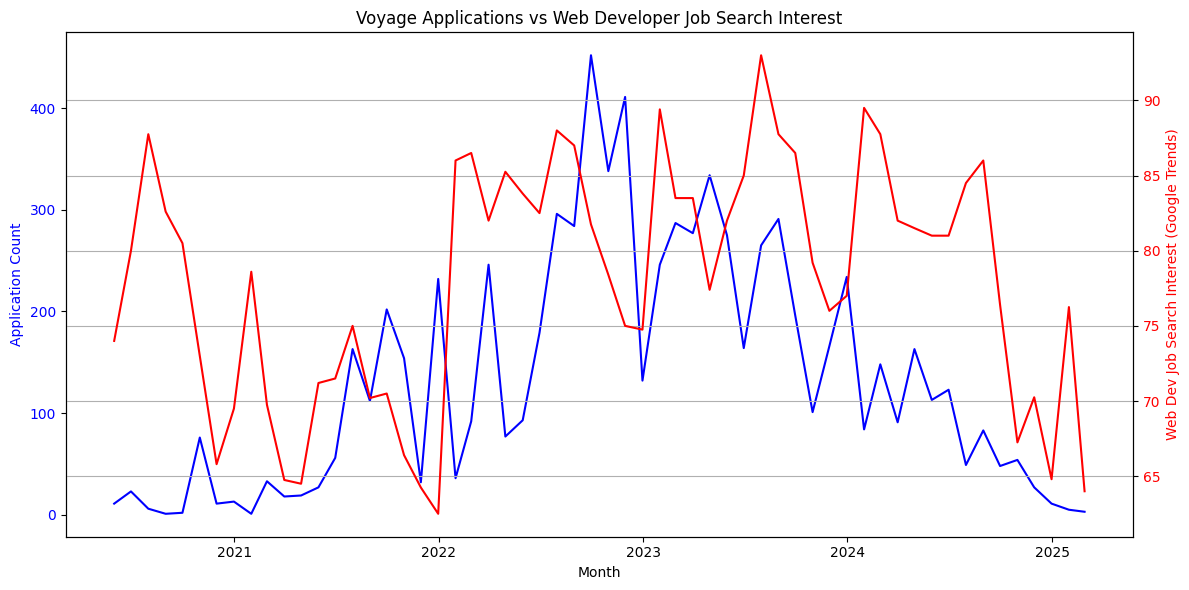

In [262]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left: Applications
ax1.set_xlabel('Month')
ax1.set_ylabel('Application Count', color='blue')
ax1.plot(comparison_df['ds'], comparison_df['application_count'], color='blue', label='Applications')
ax1.tick_params(axis='y', labelcolor='blue')

# Right: Google Search Interest
ax2 = ax1.twinx()
ax2.set_ylabel('Web Dev Job Search Interest (Google Trends)', color='red')
ax2.plot(comparison_df['ds'], comparison_df['web_search_interest'], color='red', label='Web Search Interest')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Voyage Applications vs Web Developer Job Search Interest")
fig.tight_layout()
plt.grid(True)
plt.show()

In [263]:
df_trends_SM = pd.read_csv("./data/multiTimeline_scrum_master.csv", skiprows=1)
df_trends_SM.columns = ['date', 'interest']
df_trends_SM['date'] = pd.to_datetime(df_trends_SM['date'])

In [264]:
df_trends_SM.set_index('date', inplace=True)

# Convert weekly to monthly average
monthly_trends = df_trends_SM.resample('M').mean().reset_index()
monthly_trends.rename(columns={'date': 'ds', 'interest': 'web_search_interest'}, inplace=True)

In [265]:
monthly_apps_sms = df_merged.set_index('application_date').resample('M').size().reset_index(name='application_count')
monthly_apps_sms.rename(columns={'application_date': 'ds'}, inplace=True)

In [266]:
comparison_df = pd.merge(monthly_apps_sms, monthly_trends, on='ds', how='inner')

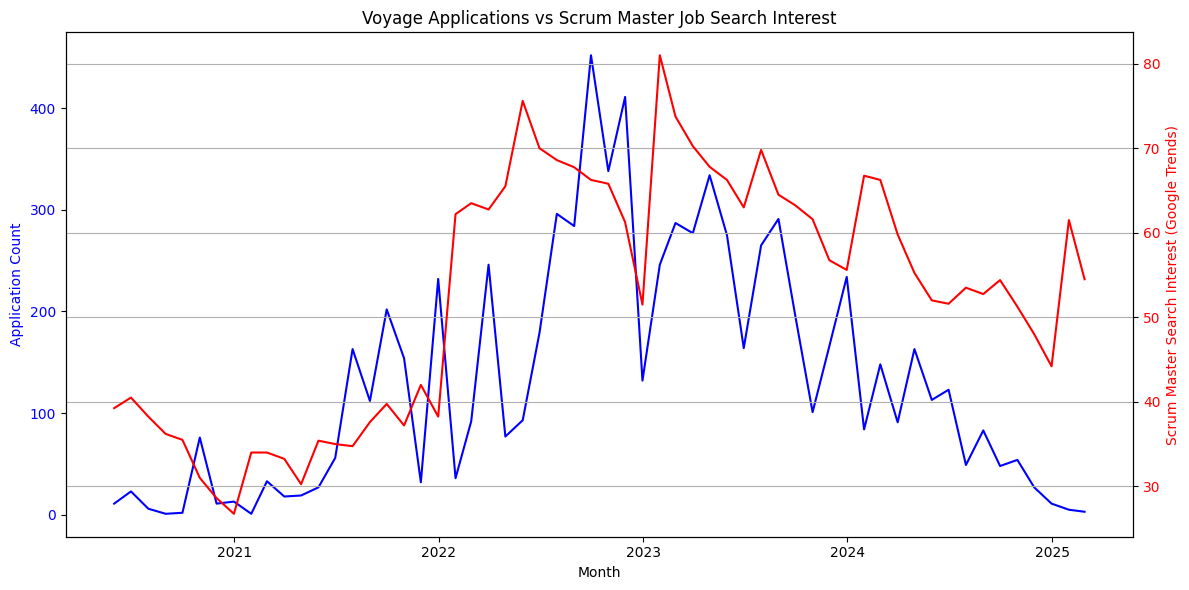

In [267]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left: Applications
ax1.set_xlabel('Month')
ax1.set_ylabel('Application Count', color='blue')
ax1.plot(comparison_df['ds'], comparison_df['application_count'], color='blue', label='Applications')
ax1.tick_params(axis='y', labelcolor='blue')

# Right: Google Search Interest
ax2 = ax1.twinx()
ax2.set_ylabel('Scrum Master Search Interest (Google Trends)', color='red')
ax2.plot(comparison_df['ds'], comparison_df['web_search_interest'], color='red', label='Web Search Interest')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Voyage Applications vs Scrum Master Job Search Interest")
fig.tight_layout()
plt.grid(True)
plt.show()

In [268]:
df_trends_PO = pd.read_csv("./data/multiTimeline_product_owner.csv", skiprows=1)
df_trends_PO.columns = ['date', 'interest']
df_trends_PO['date'] = pd.to_datetime(df_trends_PO['date'])

In [269]:
df_trends_PO.set_index('date', inplace=True)

# Convert weekly to monthly average
monthly_trends = df_trends_PO.resample('M').mean().reset_index()
monthly_trends.rename(columns={'date': 'ds', 'interest': 'web_search_interest'}, inplace=True)

In [270]:
monthly_apps_po = df_merged.set_index('application_date').resample('M').size().reset_index(name='application_count')
monthly_apps_po.rename(columns={'application_date': 'ds'}, inplace=True)

In [271]:
comparison_df_po = pd.merge(monthly_apps_sms, monthly_trends, on='ds', how='inner')

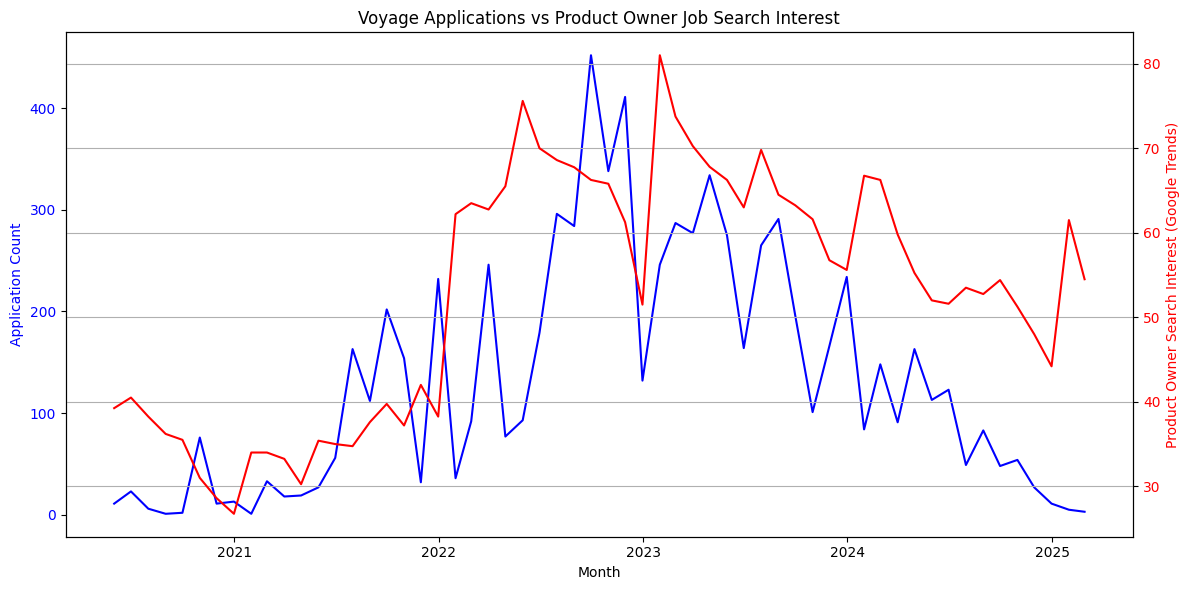

In [272]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left: Applications
ax1.set_xlabel('Month')
ax1.set_ylabel('Application Count', color='blue')
ax1.plot(comparison_df_po['ds'], comparison_df_po['application_count'], color='blue', label='Applications')
ax1.tick_params(axis='y', labelcolor='blue')

# Right: Google Search Interest
ax2 = ax1.twinx()
ax2.set_ylabel('Product Owner Search Interest (Google Trends)', color='red')
ax2.plot(comparison_df['ds'], comparison_df['web_search_interest'], color='red', label='Web Search Interest')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Voyage Applications vs Product Owner Job Search Interest")
fig.tight_layout()
plt.grid(True)
plt.show()